# 走鬼 Ghost Sweep — Data Analysis
## Alert Distribution by Police District & Region

Analyzing collected enforcement-officer sighting data mapped to Hong Kong's 21 police districts across 5 regions.

In [1]:
import sqlite3
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 11

# Connect to the SQLite database — try multiple paths
PROJECT_DIR = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
for candidate in [
    os.path.join(PROJECT_DIR, "ghost_alerts.db"),
    os.path.join(os.getcwd(), "ghost_alerts.db"),
    os.path.join(os.getcwd(), "..", "ghost_alerts.db"),
    r"C:\Users\kevlam03\OneDrive - Robert Half\Documents\Ghost_Sweep\ghost_alerts.db",
]:
    if os.path.exists(candidate):
        DB_PATH = candidate
        break
else:
    raise FileNotFoundError("ghost_alerts.db not found")

conn = sqlite3.connect(DB_PATH)
print(f"Connected to: {os.path.abspath(DB_PATH)}")

# Load all tables
df_sightings = pd.read_sql("SELECT * FROM sightings", conn)
df_events = pd.read_sql("SELECT * FROM events", conn)
df_cycles = pd.read_sql("SELECT * FROM poll_cycles", conn)

print(f"\nRaw sightings: {len(df_sightings)}")
print(f"Cleaned events: {len(df_events)}")
print(f"Poll cycles:    {len(df_cycles)}")
print(f"\nSightings columns: {list(df_sightings.columns)}")
df_sightings.head(3)

Connected to: c:\Users\kevlam03\OneDrive - Robert Half\Documents\Ghost_Sweep\ghost_alerts.db

Raw sightings: 1360
Cleaned events: 302
Poll cycles:    629

Sightings columns: ['alert_record_id', 'lat', 'lng', 'address', 'alert_type', 'create_dt', 'upvote', 'downvote', 'grid_cell', 'district', 'region', 'first_seen', 'last_seen']


,alert_record_id,lat,lng,address,alert_type,create_dt,upvote,downvote,grid_cell,district,region,first_seen,last_seen
0,5233461,22.301800,114.176058,九龍尖沙咀漆咸圍7號宏富大廈,alert,2026-06-13 11:46:21,0,0,22.300_114.175,None,None,2026-06-13T17:17:35.088941+00:00,2026-06-13T17:17:35.088941+00:00
1,5233601,22.300451,114.179019,77麼地道,alert,2026-06-13 13:07:55,0,0,22.300_114.180,None,None,2026-06-13T17:17:35.091949+00:00,2026-06-13T17:17:35.091949+00:00
2,5233602,22.300242,114.178670,1科學館廣場,alert,2026-06-13 13:08:16,0,0,22.300_114.180,None,None,2026-06-13T17:17:35.091949+00:00,2026-06-13T17:17:35.091949+00:00


## 1. District Assignment & Cleaning

Map all sightings to police districts using our nearest-station lookup, then run event consolidation.

In [2]:
import sys
sys.path.insert(0, PROJECT_DIR)
from ghost_districts import get_district, DISTRICT_STATIONS

# Assign districts to all sightings
df = df_sightings.copy()
districts_regions = df.apply(lambda row: get_district(row["lat"], row["lng"]), axis=1)
df["district"] = [dr[0] for dr in districts_regions]
df["region"] = [dr[1] for dr in districts_regions]

# Parse timestamps
df["create_dt_parsed"] = pd.to_datetime(df["create_dt"], errors="coerce")
df["hour"] = df["create_dt_parsed"].dt.hour
df["day_of_week"] = df["create_dt_parsed"].dt.day_name()
df["date"] = df["create_dt_parsed"].dt.date

# Filter valid HK coordinates
df = df[(df["lat"] > 22.1) & (df["lat"] < 22.6) & (df["lng"] > 113.8) & (df["lng"] < 114.5)]

print(f"Valid sightings with districts: {len(df)}")
print(f"Unique districts: {df['district'].nunique()}")
print(f"Date range: {df['create_dt_parsed'].min()} → {df['create_dt_parsed'].max()}")
df[["alert_record_id", "lat", "lng", "address", "district", "region", "create_dt"]].head(5)

Valid sightings with districts: 1360
Unique districts: 20
Date range: 2026-06-13 09:58:34 → 2026-06-18 17:59:05


,alert_record_id,lat,lng,address,district,region,create_dt
0,5233461,22.301800,114.176058,九龍尖沙咀漆咸圍7號宏富大廈,Yau Tsim,Kowloon West,2026-06-13 11:46:21
1,5233601,22.300451,114.179019,77麼地道,Yau Tsim,Kowloon West,2026-06-13 13:07:55
2,5233602,22.300242,114.178670,1科學館廣場,Yau Tsim,Kowloon West,2026-06-13 13:08:16
3,5233609,22.301098,114.175521,九龍尖沙咀天文臺道14-16號,Yau Tsim,Kowloon West,2026-06-13 13:14:55
4,5233625,22.302382,114.176290,"Rosary Church, Tsim Sha Tsui, Kowloon,",Yau Tsim,Kowloon West,2026-06-13 13:23:16


## 2. Distribution by Police District

Bar chart showing the number of sightings per police district, colored by region.

C:\Users\kevlam03\AppData\Local\Temp\ipykernel_43456\3794691666.py:29: UserWarning: Glyph 36208 (\N{CJK UNIFIED IDEOGRAPH-8D70}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kevlam03\AppData\Local\Temp\ipykernel_43456\3794691666.py:29: UserWarning: Glyph 39740 (\N{CJK UNIFIED IDEOGRAPH-9B3C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\kevlam03\OneDrive - Robert Half\Documents\Ghost_Sweep\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36208 (\N{CJK UNIFIED IDEOGRAPH-8D70}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kevlam03\OneDrive - Robert Half\Documents\Ghost_Sweep\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39740 (\N{CJK UNIFIED IDEOGRAPH-9B3C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


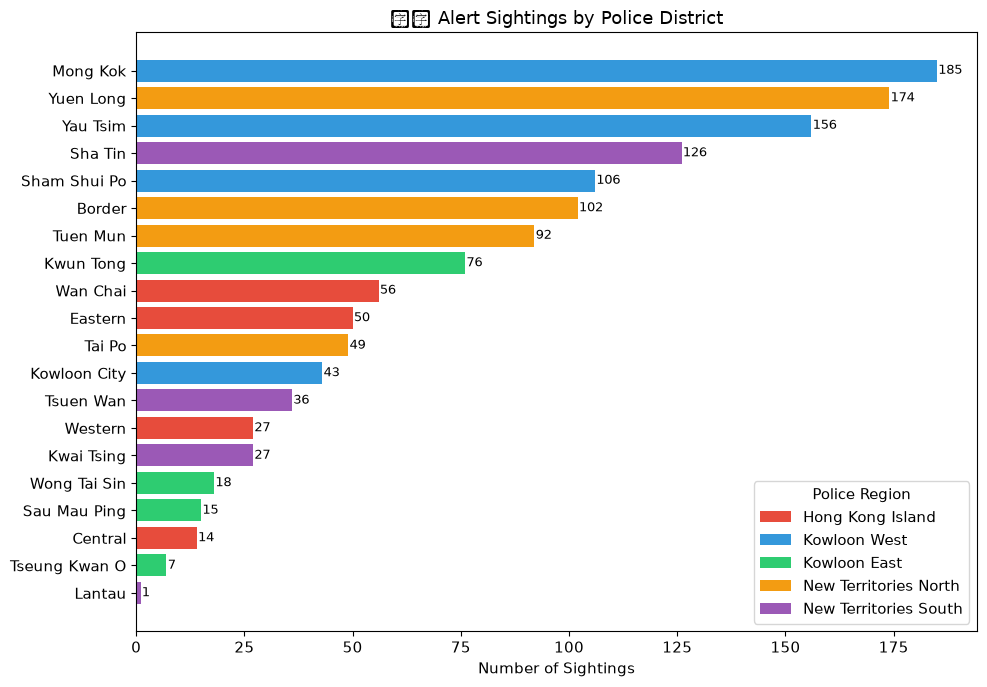

In [3]:
REGION_COLORS = {
    "Hong Kong Island": "#e74c3c",
    "Kowloon West": "#3498db",
    "Kowloon East": "#2ecc71",
    "New Territories North": "#f39c12",
    "New Territories South": "#9b59b6",
}

# Count by district
district_counts = df.groupby(["district", "region"]).size().reset_index(name="count")
district_counts = district_counts.sort_values("count", ascending=True)
district_counts["color"] = district_counts["region"].map(REGION_COLORS)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(district_counts["district"], district_counts["count"], color=district_counts["color"])
ax.set_xlabel("Number of Sightings")
ax.set_title("走鬼 Alert Sightings by Police District")

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=r) for r, c in REGION_COLORS.items()]
ax.legend(handles=legend_elements, loc="lower right", title="Police Region")

# Value labels
for bar, count in zip(bars, district_counts["count"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(count), va="center", fontsize=9)

plt.tight_layout()
plt.show()

## 3. Distribution by Police Region

Aggregated view at the region level — which of the 5 police regions has the most warden activity?

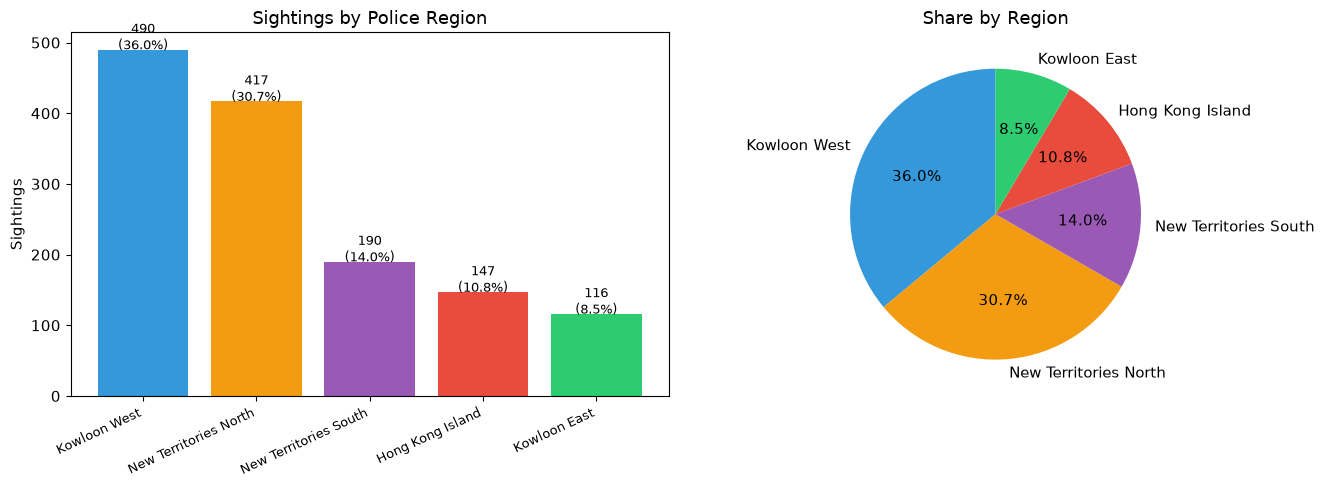


Region Summary:
               region  count  pct
         Kowloon West    490 36.0
New Territories North    417 30.7
New Territories South    190 14.0
     Hong Kong Island    147 10.8
         Kowloon East    116  8.5


In [4]:
region_counts = df.groupby("region").size().reset_index(name="count")
region_counts = region_counts.sort_values("count", ascending=False)
region_counts["color"] = region_counts["region"].map(REGION_COLORS)
region_counts["pct"] = (region_counts["count"] / region_counts["count"].sum() * 100).round(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ax1.bar(range(len(region_counts)), region_counts["count"], color=region_counts["color"])
ax1.set_xticks(range(len(region_counts)))
ax1.set_xticklabels(region_counts["region"], rotation=25, ha="right", fontsize=9)
ax1.set_ylabel("Sightings")
ax1.set_title("Sightings by Police Region")
for i, (count, pct) in enumerate(zip(region_counts["count"], region_counts["pct"])):
    ax1.text(i, count + 0.5, f"{count}\n({pct}%)", ha="center", fontsize=9)

# Pie chart
ax2.pie(region_counts["count"], labels=region_counts["region"],
        colors=region_counts["color"], autopct="%1.1f%%", startangle=90)
ax2.set_title("Share by Region")

plt.tight_layout()
plt.show()

# Summary table
print("\nRegion Summary:")
print(region_counts[["region", "count", "pct"]].to_string(index=False))

## 4. Temporal Patterns

When are wardens most active? Distribution by hour of day and day of week.

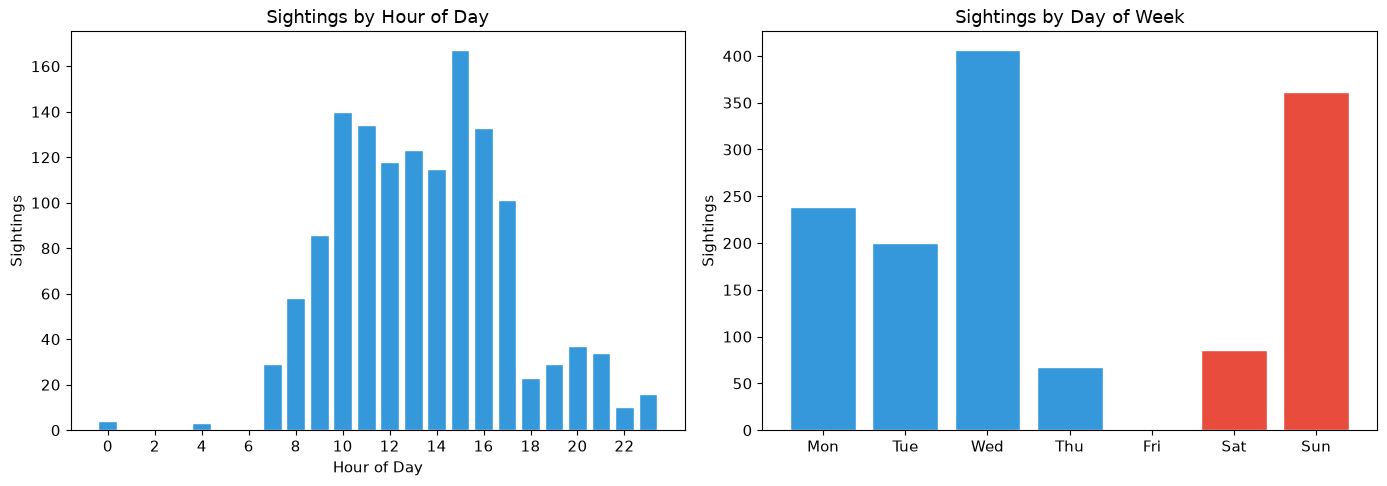

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Hour of day
hourly = df.groupby("hour").size()
ax1.bar(hourly.index, hourly.values, color="#3498db", edgecolor="white")
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Sightings")
ax1.set_title("Sightings by Hour of Day")
ax1.set_xticks(range(0, 24, 2))

# Day of week
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_counts = df["day_of_week"].value_counts().reindex(dow_order, fill_value=0)
colors = ["#3498db"] * 5 + ["#e74c3c", "#e74c3c"]  # weekends in red
ax2.bar(range(7), dow_counts.values, color=colors, edgecolor="white")
ax2.set_xticks(range(7))
ax2.set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax2.set_ylabel("Sightings")
ax2.set_title("Sightings by Day of Week")

plt.tight_layout()
plt.show()

## 5. Scatter Map — All Sightings by District

Geographic scatter plot of all alert coordinates, colored by police district.

C:\Users\kevlam03\AppData\Local\Temp\ipykernel_43456\2863910946.py:18: UserWarning: Glyph 36208 (\N{CJK UNIFIED IDEOGRAPH-8D70}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kevlam03\AppData\Local\Temp\ipykernel_43456\2863910946.py:18: UserWarning: Glyph 39740 (\N{CJK UNIFIED IDEOGRAPH-9B3C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\kevlam03\OneDrive - Robert Half\Documents\Ghost_Sweep\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36208 (\N{CJK UNIFIED IDEOGRAPH-8D70}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\kevlam03\OneDrive - Robert Half\Documents\Ghost_Sweep\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39740 (\N{CJK UNIFIED IDEOGRAPH-9B3C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


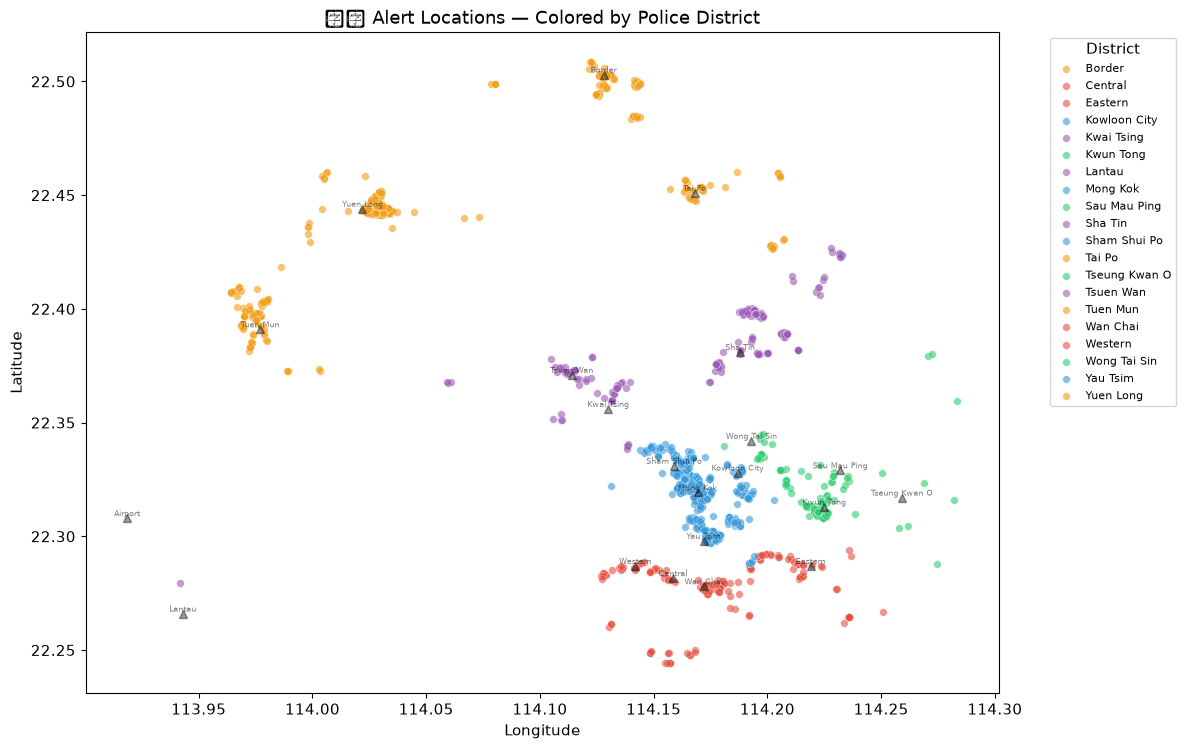

In [6]:
fig, ax = plt.subplots(figsize=(12, 10))

for district, group in df.groupby("district"):
    region = group["region"].iloc[0]
    color = REGION_COLORS.get(region, "#999")
    ax.scatter(group["lng"], group["lat"], c=color, s=30, alpha=0.6, label=district, edgecolors="white", linewidth=0.3)

# Add district station markers
for name, info in DISTRICT_STATIONS.items():
    ax.plot(info["lng"], info["lat"], "k^", markersize=6, alpha=0.4)
    ax.annotate(name, (info["lng"], info["lat"]), fontsize=6, alpha=0.5, ha="center", va="bottom")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("走鬼 Alert Locations — Colored by Police District")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8, title="District")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 6. Interactive Folium Map

Interactive map of Hong Kong with alert markers, colored by district. Click markers for details.

In [7]:
import folium
from folium.plugins import MarkerCluster

FOLIUM_COLORS = {
    "Hong Kong Island": "red",
    "Kowloon West": "blue",
    "Kowloon East": "green",
    "New Territories North": "orange",
    "New Territories South": "purple",
}

m = folium.Map(location=[22.35, 114.15], zoom_start=11, tiles="CartoDB positron")
cluster = MarkerCluster().add_to(m)

for _, row in df.iterrows():
    color = FOLIUM_COLORS.get(row["region"], "gray")
    popup = f"<b>{row['address']}</b><br>District: {row['district']}<br>Region: {row['region']}<br>Time: {row['create_dt']}<br>Upvotes: {row['upvote']}"
    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=popup,
    ).add_to(cluster)

# Add legend
legend_html = '<div style="position:fixed;bottom:30px;left:30px;z-index:999;background:white;padding:10px;border:1px solid #ccc;border-radius:5px;font-size:12px;">'
legend_html += "<b>Police Regions</b><br>"
for region, color in FOLIUM_COLORS.items():
    legend_html += f'<span style="color:{color}">●</span> {region}<br>'
legend_html += "</div>"
m.get_root().html.add_child(folium.Element(legend_html))

m

In [8]:
# Save map as standalone HTML — open this in your browser
map_path = os.path.join(PROJECT_DIR, "analysis", "ghost_map.html")
m.save(map_path)
print(f"Map saved to: {os.path.abspath(map_path)}")
print("Open this file in your browser to see the interactive map.")

Map saved to: c:\Users\kevlam03\OneDrive - Robert Half\Documents\Ghost_Sweep\analysis\ghost_map.html
Open this file in your browser to see the interactive map.


## 7. Statistical Summary

Descriptive stats per district — which zones are busiest, which are quiet.

In [9]:
# Full district summary
summary = df.groupby(["region", "district"]).agg(
    sightings=("alert_record_id", "count"),
    avg_upvotes=("upvote", "mean"),
    total_upvotes=("upvote", "sum"),
    first_seen=("create_dt_parsed", "min"),
    last_seen=("create_dt_parsed", "max"),
).round(1).sort_values("sightings", ascending=False)

print("=" * 80)
print("GHOST SWEEP — POLICE DISTRICT ANALYSIS")
print("=" * 80)
print(f"\nTotal sightings analyzed: {len(df)}")
print(f"Active districts: {df['district'].nunique()} / 21")
print(f"Active regions: {df['region'].nunique()} / 5")
print(f"\nTop 5 busiest districts:")
print(summary.head(5).to_string())

# Per-district stats
zone_counts = df.groupby("district").size()
print(f"\n\nDescriptive Statistics (sightings per district):")
print(f"  Mean:   {zone_counts.mean():.1f}")
print(f"  Median: {zone_counts.median():.1f}")
print(f"  Std:    {zone_counts.std():.1f}")
print(f"  Min:    {zone_counts.min()} ({zone_counts.idxmin()})")
print(f"  Max:    {zone_counts.max()} ({zone_counts.idxmax()})")

# Districts with zero sightings
all_districts = set(DISTRICT_STATIONS.keys())
active_districts = set(df["district"].unique())
inactive = all_districts - active_districts
if inactive:
    print(f"\nDistricts with ZERO sightings ({len(inactive)}):")
    for d in sorted(inactive):
        print(f"  - {d} ({DISTRICT_STATIONS[d]['region']})")

GHOST SWEEP — POLICE DISTRICT ANALYSIS

Total sightings analyzed: 1360
Active districts: 20 / 21
Active regions: 5 / 5

Top 5 busiest districts:
                                    sightings  avg_upvotes  total_upvotes          first_seen           last_seen
region                district                                                                                   
Kowloon West          Mong Kok            185          0.0              1 2026-06-13 22:34:35 2026-06-18 17:25:14
New Territories North Yuen Long           174          0.0              3 2026-06-13 09:58:34 2026-06-18 17:39:32
Kowloon West          Yau Tsim            156          0.0              0 2026-06-13 11:46:21 2026-06-18 17:57:43
New Territories South Sha Tin             126          0.0              2 2026-06-14 00:34:58 2026-06-17 16:52:06
Kowloon West          Sham Shui Po        106          0.0              0 2026-06-14 09:38:24 2026-06-18 17:49:36


Descriptive Statistics (sightings per district):
  Mean

C:\Users\kevlam03\AppData\Local\Temp\ipykernel_43456\2410783493.py:8: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ).round(1).sort_values("sightings", ascending=False)
